In [2]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display


In [3]:
def find_project_root(start: Path) -> Path:
    cur = start.resolve()
    for p in [cur] + list(cur.parents):
        if (p / "src").is_dir() and (p / "data").is_dir():
            return p
    raise RuntimeError(f"Could not find project root starting from {start}")

cwd = Path.cwd()
PROJECT_ROOT = find_project_root(cwd)
print("CWD         :", cwd)
print("PROJECT_ROOT:", PROJECT_ROOT)

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))
print("project_root in sys.path:", str(PROJECT_ROOT) in sys.path)

analysis_dir = PROJECT_ROOT / "analysis"
print("Analysis dir:", analysis_dir)


CWD         : /home/hpc/iwi5/iwi5384h/projects/handwriting_forge_project/notebooks
PROJECT_ROOT: /home/hpc/iwi5/iwi5384h/projects/handwriting_forge_project
project_root in sys.path: True
Analysis dir: /home/hpc/iwi5/iwi5384h/projects/handwriting_forge_project/analysis


In [4]:
VIT_TAGS = [
    "vit_baseline",
    "vit_A1_geo",
    "vit_A2_photo",
    "vit_A3_norm",
    "vit_A4_realistic",
    "vit_A5_noisy",
]

def load_tsne_df(tag: str) -> pd.DataFrame:
    path = analysis_dir / f"{tag}_tsne.csv"
    df = pd.read_csv(path)
    print(f"[{tag}] t-SNE df shape:", df.shape)
    return df

def load_test_results_df(tag: str) -> pd.DataFrame:
    path = analysis_dir / f"{tag}_test_results.csv"
    df = pd.read_csv(path)
    print(f"[{tag}] test_results df shape:", df.shape)
    return df


[vit_baseline] t-SNE df shape: (1500, 8)


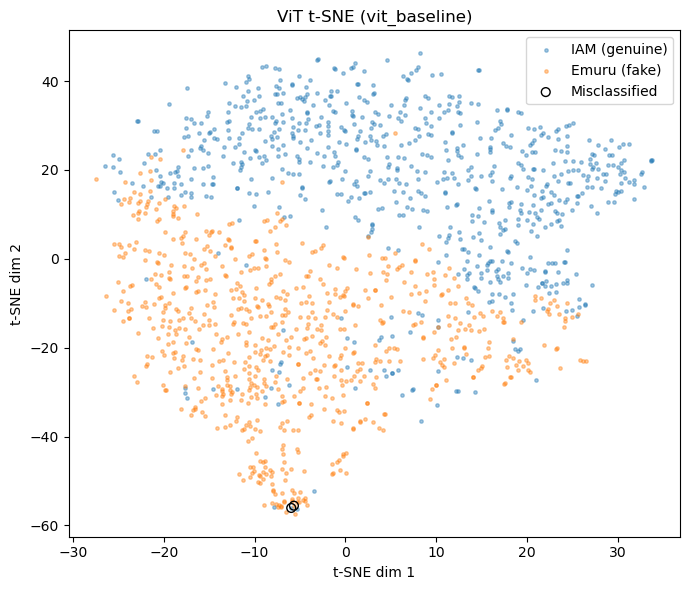

In [5]:
TAG = "vit_baseline"  # change to any vit_* tag you analyzed with --tsne

tsne_df = load_tsne_df(TAG)

iam_mask = (tsne_df["true_label"].to_numpy() == 0)
emu_mask = (tsne_df["true_label"].to_numpy() == 1)
mis_mask = (tsne_df["true_label"] != tsne_df["pred_label"]).to_numpy()

plt.figure(figsize=(7, 6))

plt.scatter(
    tsne_df.loc[iam_mask, "tsne_x"],
    tsne_df.loc[iam_mask, "tsne_y"],
    s=6, alpha=0.4,
    label="IAM (genuine)",
)

plt.scatter(
    tsne_df.loc[emu_mask, "tsne_x"],
    tsne_df.loc[emu_mask, "tsne_y"],
    s=6, alpha=0.4,
    label="Emuru (fake)",
)

if mis_mask.any():
    plt.scatter(
        tsne_df.loc[mis_mask, "tsne_x"],
        tsne_df.loc[mis_mask, "tsne_y"],
        s=40,
        edgecolors="k", facecolors="none",
        linewidths=1.0,
        label="Misclassified",
    )

plt.title(f"ViT t-SNE ({TAG})")
plt.xlabel("t-SNE dim 1")
plt.ylabel("t-SNE dim 2")
plt.legend()
plt.tight_layout()
plt.show()


[vit_baseline] t-SNE df shape: (1500, 8)
[vit_A4_realistic] t-SNE df shape: (1500, 8)
[vit_A5_noisy] t-SNE df shape: (1500, 8)


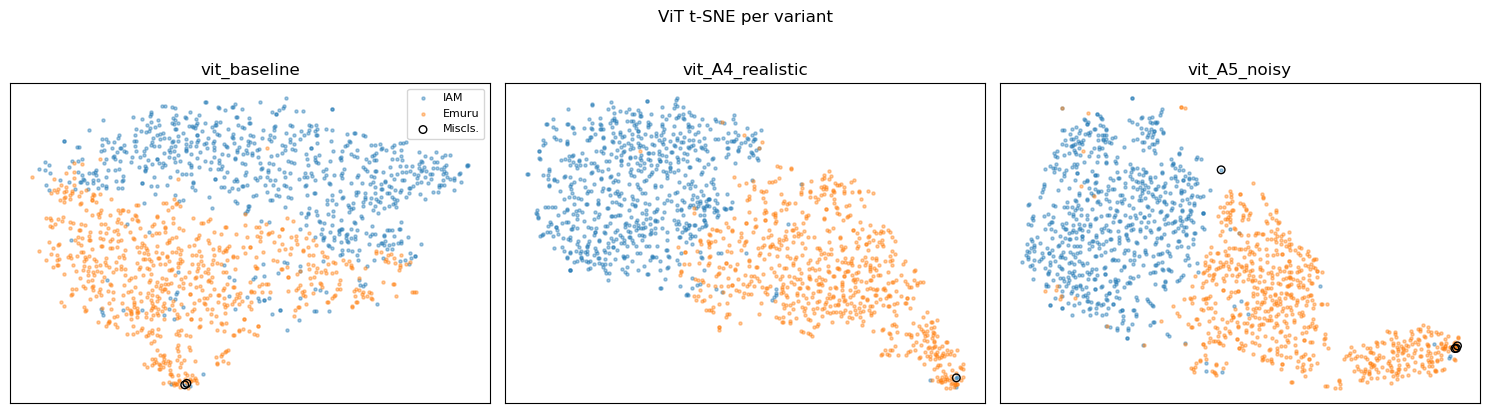

In [6]:
TAGS_FOR_GRID = [
    "vit_baseline",
    "vit_A4_realistic",
    "vit_A5_noisy",
]

n = len(TAGS_FOR_GRID)
cols = 3
rows = int(np.ceil(n / cols))

plt.figure(figsize=(5 * cols, 4 * rows))

for i, tag in enumerate(TAGS_FOR_GRID, start=1):
    tsne_df = load_tsne_df(tag)
    iam_mask = (tsne_df["true_label"].to_numpy() == 0)
    emu_mask = (tsne_df["true_label"].to_numpy() == 1)
    mis_mask = (tsne_df["true_label"] != tsne_df["pred_label"]).to_numpy()

    ax = plt.subplot(rows, cols, i)

    ax.scatter(
        tsne_df.loc[iam_mask, "tsne_x"],
        tsne_df.loc[iam_mask, "tsne_y"],
        s=5, alpha=0.4,
        label="IAM",
    )
    ax.scatter(
        tsne_df.loc[emu_mask, "tsne_x"],
        tsne_df.loc[emu_mask, "tsne_y"],
        s=5, alpha=0.4,
        label="Emuru",
    )

    if mis_mask.any():
        ax.scatter(
            tsne_df.loc[mis_mask, "tsne_x"],
            tsne_df.loc[mis_mask, "tsne_y"],
            s=30,
            edgecolors="k", facecolors="none",
            linewidths=1.0,
            label="Miscls.",
        )

    ax.set_title(tag)
    ax.set_xticks([])
    ax.set_yticks([])

    if i == 1:
        ax.legend(fontsize=8)

plt.suptitle("ViT t-SNE per variant", y=1.02)
plt.tight_layout()
plt.show()


[vit_baseline] test_results df shape: (5506, 6)
[vit_A1_geo] test_results df shape: (5506, 6)
[vit_A2_photo] test_results df shape: (5506, 6)
[vit_A3_norm] test_results df shape: (5506, 6)
[vit_A4_realistic] test_results df shape: (5506, 6)
[vit_A5_noisy] test_results df shape: (5506, 6)


,tag,accuracy
1,vit_A1_geo,0.999818
2,vit_A2_photo,0.993098
3,vit_A3_norm,0.997276
4,vit_A4_realistic,0.998729
5,vit_A5_noisy,0.997276
0,vit_baseline,0.998729


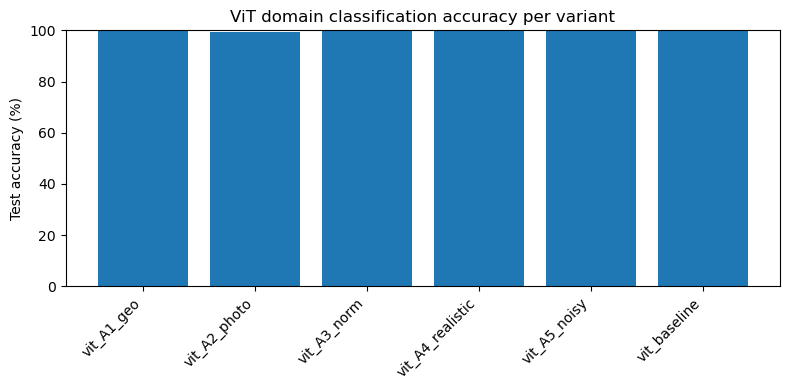

In [7]:
acc_rows = []

for tag in VIT_TAGS:
    try:
        df_res = load_test_results_df(tag)
    except FileNotFoundError:
        print(f"[{tag}] test_results CSV not found, skipping.")
        continue

    acc = (df_res["true_label"] == df_res["pred_label"]).mean()
    acc_rows.append({"tag": tag, "accuracy": acc})

acc_df = pd.DataFrame(acc_rows).sort_values("tag")
display(acc_df)

plt.figure(figsize=(8, 4))
plt.bar(acc_df["tag"], acc_df["accuracy"] * 100.0)
plt.xticks(rotation=45, ha="right")
plt.ylabel("Test accuracy (%)")
plt.title("ViT domain classification accuracy per variant")
plt.ylim(0, 100)
plt.tight_layout()
plt.show()


[vit_baseline] test_results df shape: (5506, 6)
[vit_A1_geo] test_results df shape: (5506, 6)
[vit_A2_photo] test_results df shape: (5506, 6)
[vit_A3_norm] test_results df shape: (5506, 6)
[vit_A4_realistic] test_results df shape: (5506, 6)
[vit_A5_noisy] test_results df shape: (5506, 6)


,tag,acc_iam,acc_emuru
1,vit_A1_geo,0.999637,1.000000
2,vit_A2_photo,0.998547,0.987650
3,vit_A3_norm,0.998184,0.996368
4,vit_A4_realistic,0.998184,0.999274
5,vit_A5_noisy,0.997457,0.997094
0,vit_baseline,0.998547,0.998910


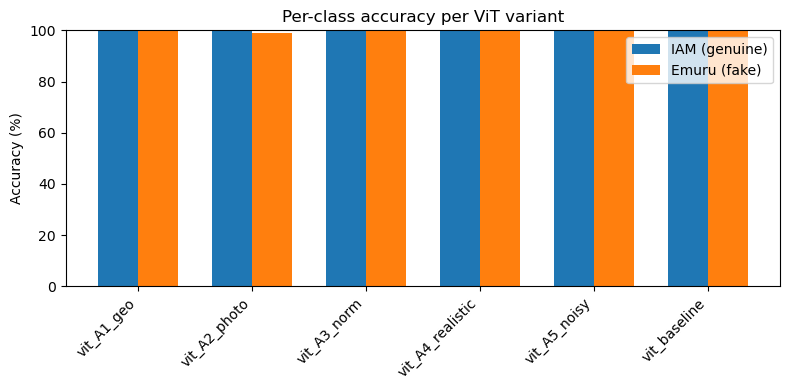

In [8]:
rows = []

for tag in VIT_TAGS:
    try:
        df_res = load_test_results_df(tag)
    except FileNotFoundError:
        continue

    y_true = df_res["true_label"].to_numpy()
    y_pred = df_res["pred_label"].to_numpy()

    mask_iam = (y_true == 0)
    mask_emu = (y_true == 1)

    acc_iam = (y_pred[mask_iam] == 0).mean() if mask_iam.any() else np.nan
    acc_emu = (y_pred[mask_emu] == 1).mean() if mask_emu.any() else np.nan

    rows.append({"tag": tag, "acc_iam": acc_iam, "acc_emuru": acc_emu})

per_class_df = pd.DataFrame(rows).sort_values("tag")
display(per_class_df)

x = np.arange(len(per_class_df))
width = 0.35

plt.figure(figsize=(8, 4))
plt.bar(x - width/2, per_class_df["acc_iam"] * 100.0, width, label="IAM (genuine)")
plt.bar(x + width/2, per_class_df["acc_emuru"] * 100.0, width, label="Emuru (fake)")

plt.xticks(x, per_class_df["tag"], rotation=45, ha="right")
plt.ylabel("Accuracy (%)")
plt.title("Per-class accuracy per ViT variant")
plt.ylim(0, 100)
plt.legend()
plt.tight_layout()
plt.show()


[vit_A4_realistic] test_results df shape: (5506, 6)
Misclassified: 7


,true_label,pred_label,prob_fake,source,idx,text,filepath,domain_label
0,0,1,0.903845,iam,8862,"with a book on the life of Marx ,",data/raw/iam/iam_08862.png,0
1,1,0,0.209620,emuru,8759,because no machinery was provided for,data/raw/emuru_A4/iam_08759_sentence.png,1
2,0,1,0.574239,iam,9707,weren't worried . We 're going to,data/raw/iam/iam_09707.png,0
3,0,1,0.896402,iam,10116,----------------------------------------------...,data/raw/iam/iam_10116.png,0
4,1,0,0.254398,emuru,8755,"arithmetic which argued that , as the first",data/raw/emuru_A4/iam_08755_sentence.png,1
5,0,1,0.511553,iam,8681,in the pay of landed Lords .,data/raw/iam/iam_08681.png,0
6,0,1,0.894543,iam,8263,in circumstances pointing to murder .,data/raw/iam/iam_08263.png,0


idx: 8862 | source: iam
true_label: 0 | pred_label: 1 | prob_fake: 0.9038
text: 'with a book on the life of Marx ,'
filepath: /home/hpc/iwi5/iwi5384h/projects/handwriting_forge_project/data/raw/iam/iam_08862.png


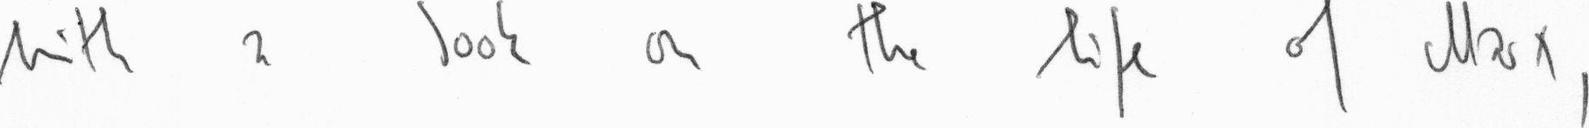

idx: 8759 | source: emuru
true_label: 1 | pred_label: 0 | prob_fake: 0.2096
text: 'because no machinery was provided for'
filepath: /home/hpc/iwi5/iwi5384h/projects/handwriting_forge_project/data/raw/emuru_A4/iam_08759_sentence.png


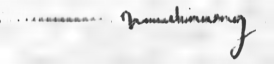

idx: 9707 | source: iam
true_label: 0 | pred_label: 1 | prob_fake: 0.5742
text: "weren't worried . We 're going to"
filepath: /home/hpc/iwi5/iwi5384h/projects/handwriting_forge_project/data/raw/iam/iam_09707.png


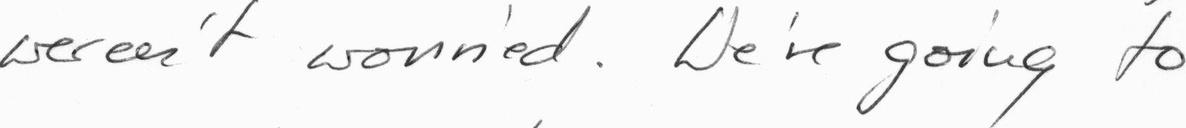

idx: 10116 | source: iam
true_label: 0 | pred_label: 1 | prob_fake: 0.8964
text: '-----------------------------------------------------'
filepath: /home/hpc/iwi5/iwi5384h/projects/handwriting_forge_project/data/raw/iam/iam_10116.png


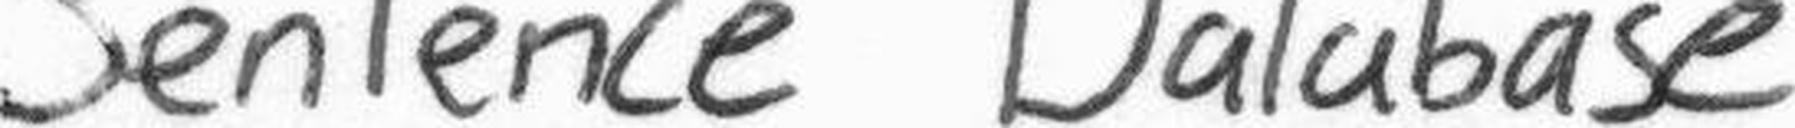

idx: 8755 | source: emuru
true_label: 1 | pred_label: 0 | prob_fake: 0.2544
text: 'arithmetic which argued that , as the first'
filepath: /home/hpc/iwi5/iwi5384h/projects/handwriting_forge_project/data/raw/emuru_A4/iam_08755_sentence.png


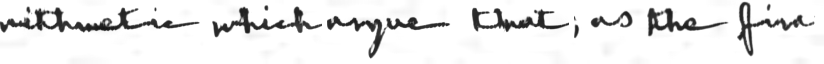

idx: 8681 | source: iam
true_label: 0 | pred_label: 1 | prob_fake: 0.5116
text: 'in the pay of landed Lords .'
filepath: /home/hpc/iwi5/iwi5384h/projects/handwriting_forge_project/data/raw/iam/iam_08681.png


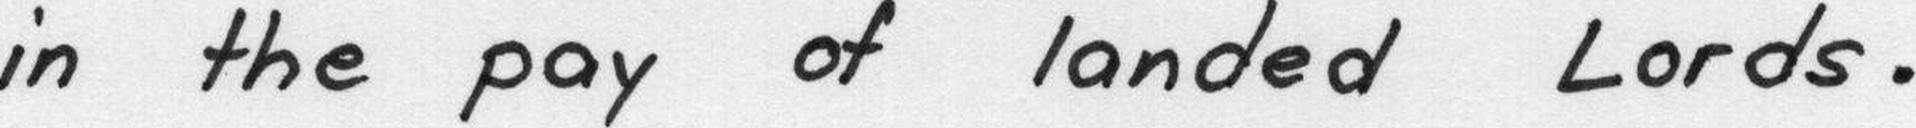

idx: 8263 | source: iam
true_label: 0 | pred_label: 1 | prob_fake: 0.8945
text: 'in circumstances pointing to murder .'
filepath: /home/hpc/iwi5/iwi5384h/projects/handwriting_forge_project/data/raw/iam/iam_08263.png


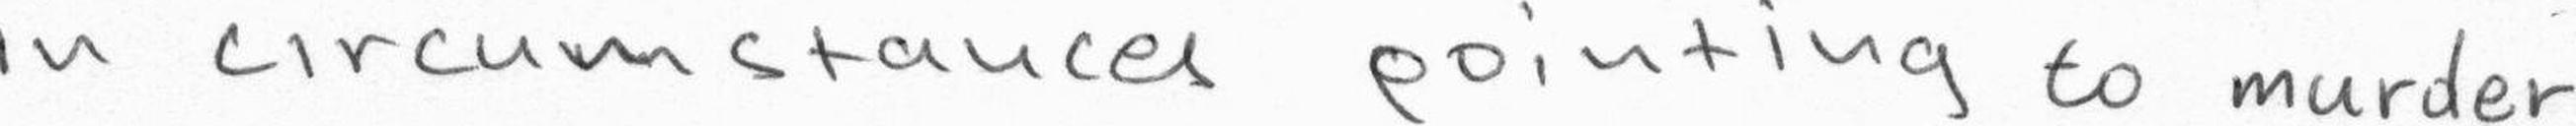

In [9]:
from PIL import Image

# Pick tag + correct dataset CSV for that variant
TAG = "vit_A4_realistic"
CSV_PATH = PROJECT_ROOT / "data" / "processed" / "metadata" / "domain_classification_sentences_A4_emuru_realistic.csv"

df_full = pd.read_csv(CSV_PATH)
df_test = df_full[df_full["hf_split"] == "test"].copy()

res = load_test_results_df(TAG)

mis = res[res["true_label"] != res["pred_label"]].copy()
print("Misclassified:", len(mis))

if len(mis) == 0:
    print("No misclassifications. Showing borderline (prob_fake closest to 0.5).")
    res["dist_to_0_5"] = (res["prob_fake"] - 0.5).abs()
    show = res.sort_values("dist_to_0_5").head(8)
else:
    show = mis.head(8)

show = show.merge(
    df_test[["idx", "source", "filepath", "domain_label"]],
    on=["idx", "source"],
    how="left",
)

display(show)

for _, row in show.iterrows():
    print("=" * 80)
    print(f"idx: {row['idx']} | source: {row['source']}")
    print(f"true_label: {row['true_label']} | pred_label: {row['pred_label']} | prob_fake: {row['prob_fake']:.4f}")
    print(f"text: {repr(row['text'])}")

    fp = row.get("filepath", None)
    if isinstance(fp, str) and len(fp) > 0:
        img_path = PROJECT_ROOT / fp
        print("filepath:", img_path)
        try:
            img = Image.open(img_path).convert("L")
            display(img)
        except Exception as e:
            print("Could not load image:", e)
    else:
        print("No filepath found after merge.")
